c:\Users\lensh\Downloads\clustering_app\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Shape: (200, 5)
Columns: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB
None
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   

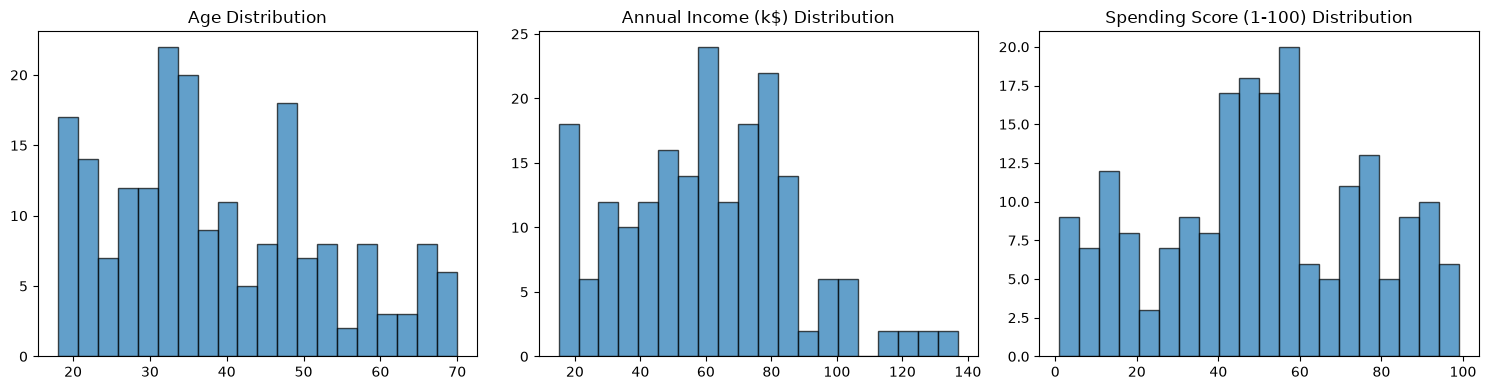

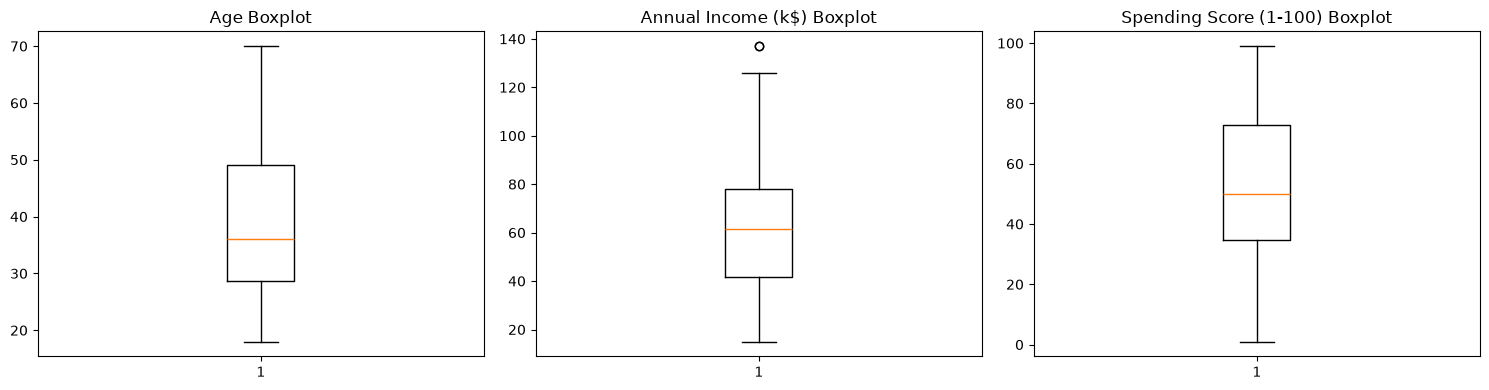

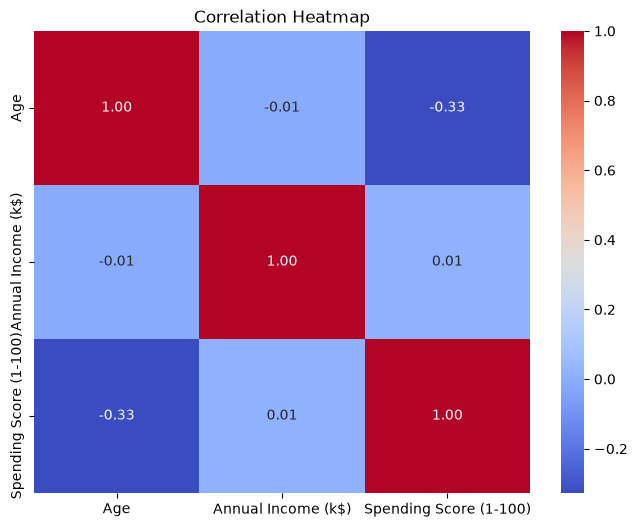

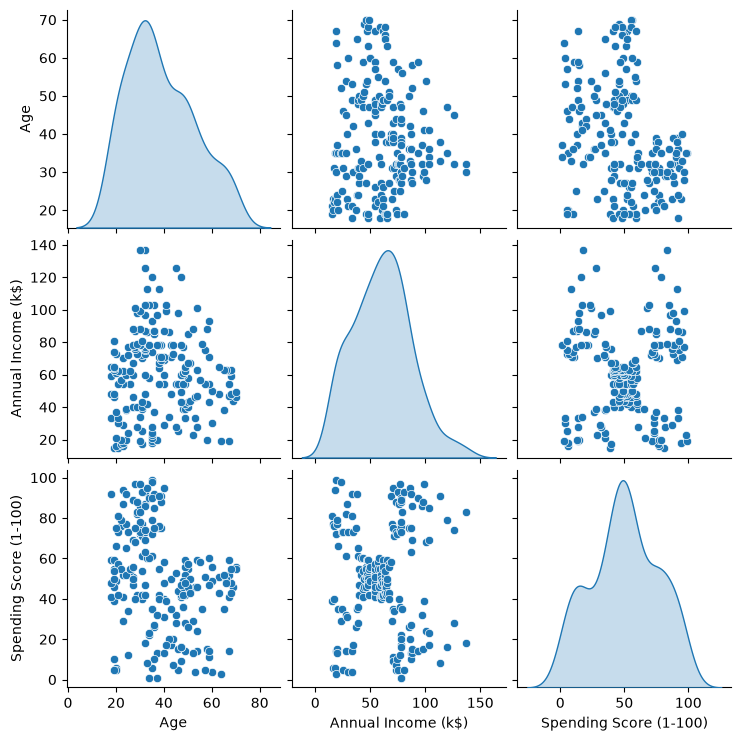

n=2: Silhouette=0.3180, DB=1.3083
n=3: Silhouette=0.3215, DB=1.1277
n=4: Silhouette=0.3615, DB=1.0164
n=5: Silhouette=0.3900, DB=0.9163
n=6: Silhouette=0.4201, DB=0.8521
n=7: Silhouette=0.3983, DB=0.8513
n=8: Silhouette=0.3665, DB=0.8416
n=9: Silhouette=0.3754, DB=0.8582
n=10: Silhouette=0.3809, DB=0.8855


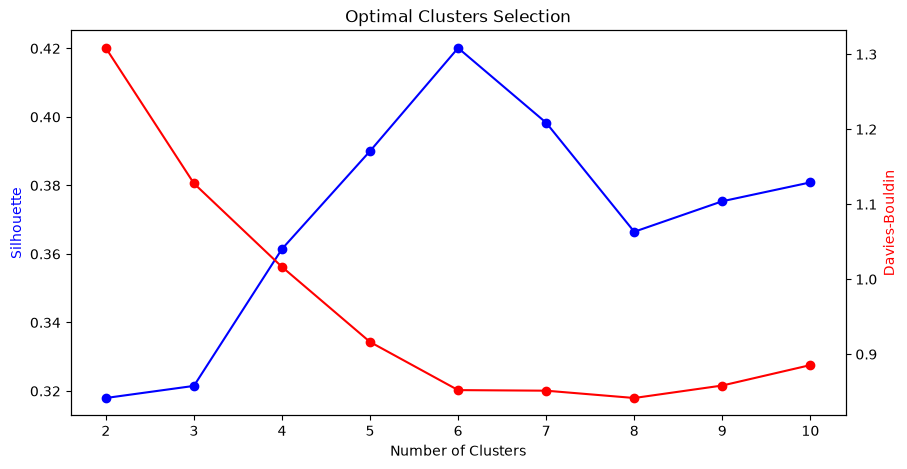

    linkage  silhouette      DB        CH
0      ward      0.3900  0.9163  107.8266
1  complete      0.4000  0.8848  121.4377
2   average      0.4096  0.9203  116.4824
3    single      0.0030  0.6288    3.2768


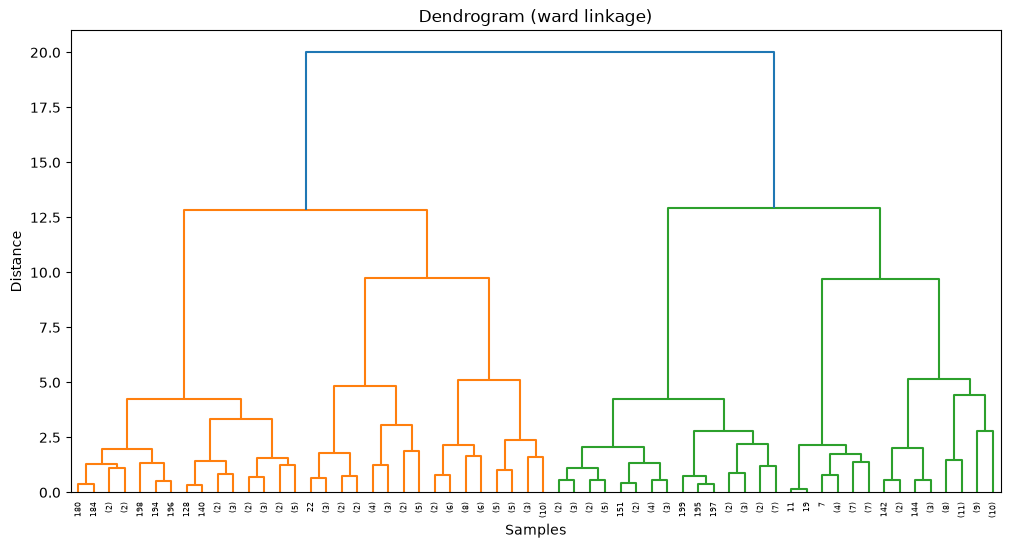

Silhouette Score: 0.3900  (higher is better)
Davies-Bouldin Index: 0.9163  (lower is better)
Calinski-Harabasz Index: 107.83  (higher is better)


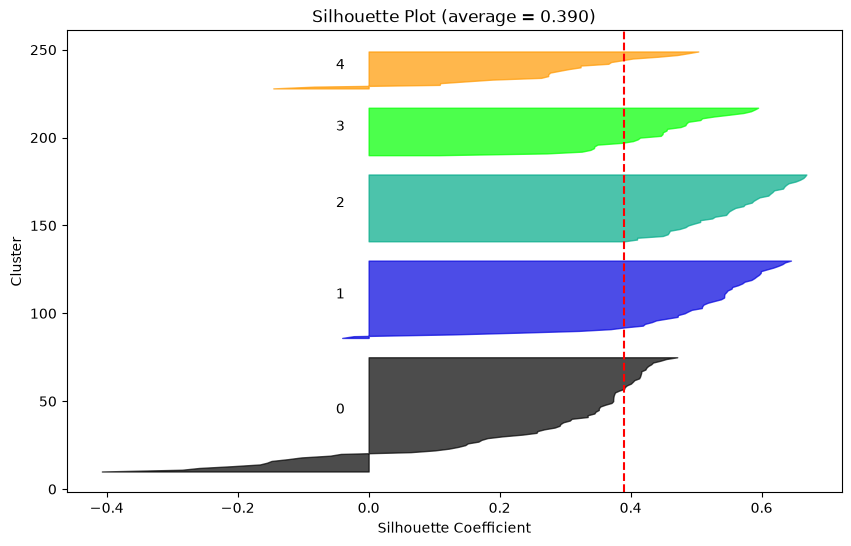


=== Cluster Profiles (Mean Values) ===
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        26.560606           47.363636               56.787879
1        56.400000           55.288889               48.355556
2        32.692308           86.538462               82.128205
3        43.892857           91.285714               16.678571
4        44.318182           25.772727               20.272727


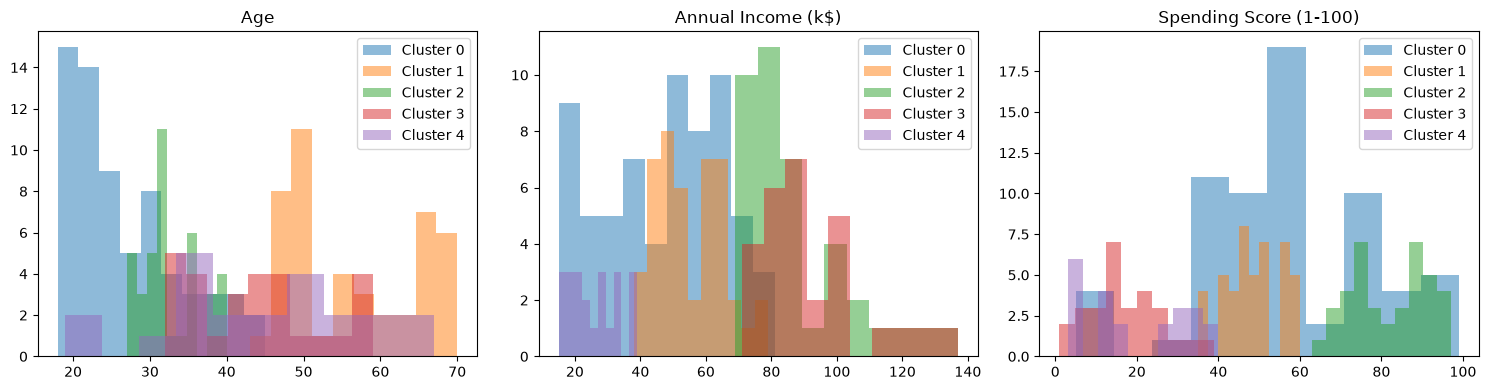


=== Assigned Cluster Names ===
Cluster 0: Medium Income, Medium Spenders
Cluster 1: Medium Income, Medium Spenders
Cluster 2: High Income, High Spenders
Cluster 3: High Income, Low Spenders
Cluster 4: Low Income, Low Spenders

=== Outlier Detection ===
Total outliers detected: 10 (5% of data)
Outlier cluster distribution:
Cluster
2    10
Name: count, dtype: int64
Percentage of data flagged as noise/outliers: 5.0%


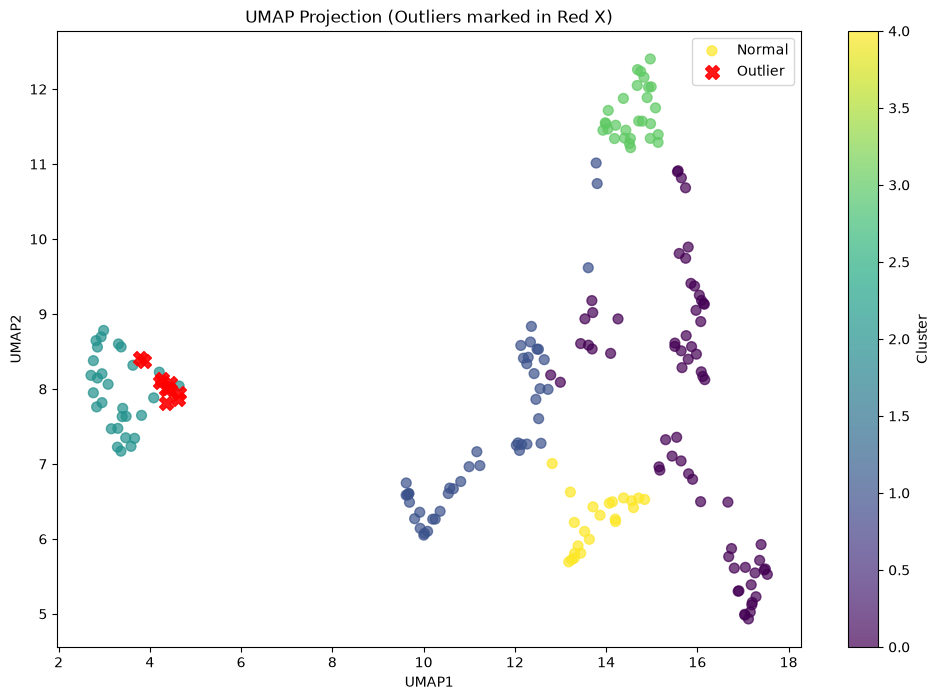


✅ All models and artifacts saved successfully!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os  

# Create folders
os.makedirs('../figures', exist_ok=True)
os.makedirs('../models', exist_ok=True)

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
import umap
import joblib
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. LOAD DATA
# ============================================================================
df = pd.read_csv('../data/Mall_Customers.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

# ============================================================================
# 2. EDA
# ============================================================================
print(df.info())
print(df.isnull().sum())
print(df.describe())
print(f"Duplicates: {df.duplicated().sum()}")

# Distribution histograms
fig, axes = plt.subplots(1, 3, figsize=(15,4))
numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=20, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col} Distribution')
plt.tight_layout()
plt.savefig('../figures/distributions.png')
plt.show()

# Boxplots for outliers
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(f'{col} Boxplot')
plt.tight_layout()
plt.savefig('../figures/boxplots.png')
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.savefig('../figures/correlation_heatmap.png')
plt.show()

# Pairplot
sns.pairplot(df[numeric_cols], diag_kind='kde')
plt.savefig('../figures/pairplot.png')
plt.show()

# ============================================================================
# 3. PREPROCESSING
# ============================================================================
# Encode Genre (NOT Gender - your CSV uses 'Genre')
le = LabelEncoder()
df['Genre_Encoded'] = le.fit_transform(df['Genre'])  # Male=1, Female=0

# Features for clustering
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].copy()

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================================
# 4. FIND OPTIMAL CLUSTERS
# ============================================================================
range_clusters = range(2, 11)
sil_scores, db_scores = [], []

for n in range_clusters:
    cluster = AgglomerativeClustering(n_clusters=n, linkage='ward', metric='euclidean')
    labels = cluster.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    print(f"n={n}: Silhouette={sil_scores[-1]:.4f}, DB={db_scores[-1]:.4f}")

# Plot
fig, ax1 = plt.subplots(figsize=(10,5))
ax2 = ax1.twinx()
ax1.plot(range_clusters, sil_scores, 'bo-', label='Silhouette')
ax2.plot(range_clusters, db_scores, 'ro-', label='Davies-Bouldin')
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('Silhouette', color='b')
ax2.set_ylabel('Davies-Bouldin', color='r')
plt.title('Optimal Clusters Selection')
plt.savefig('../figures/optimal_clusters.png')
plt.show()

# ============================================================================
# 5. COMPARE LINKAGE METHODS
# ============================================================================
linkage_methods = ['ward', 'complete', 'average', 'single']
results = []
for method in linkage_methods:
    # Ward only works with euclidean
    metric = 'euclidean' if method == 'ward' else 'euclidean'
    cluster = AgglomerativeClustering(n_clusters=5, linkage=method, metric=metric)
    labels = cluster.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    results.append({'linkage': method, 'silhouette': sil, 'DB': db, 'CH': ch})
print(pd.DataFrame(results).round(4))

# ============================================================================
# 6. TRAIN FINAL MODEL
# ============================================================================
BEST_N = 5
BEST_LINKAGE = 'ward'
BEST_METRIC = 'euclidean'

final_cluster = AgglomerativeClustering(
    n_clusters=BEST_N, 
    linkage=BEST_LINKAGE, 
    metric=BEST_METRIC
)
cluster_labels = final_cluster.fit_predict(X_scaled)
df['Cluster'] = cluster_labels

# Dendrogram
plt.figure(figsize=(12,6))
linkage_matrix = linkage(X_scaled, method=BEST_LINKAGE, metric=BEST_METRIC)
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title(f'Dendrogram ({BEST_LINKAGE} linkage)')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.savefig('../figures/dendrogram.png')
plt.show()

# ============================================================================
# 7. EVALUATION METRICS
# ============================================================================
sil = silhouette_score(X_scaled, cluster_labels)
db = davies_bouldin_score(X_scaled, cluster_labels)
ch = calinski_harabasz_score(X_scaled, cluster_labels)

print(f"Silhouette Score: {sil:.4f}  (higher is better)")
print(f"Davies-Bouldin Index: {db:.4f}  (lower is better)")
print(f"Calinski-Harabasz Index: {ch:.2f}  (higher is better)")

# Silhouette plot
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(10,6))
sil_vals = silhouette_samples(X_scaled, cluster_labels)
y_lower = 10
for i in range(BEST_N):
    cluster_sil = sil_vals[cluster_labels == i]
    cluster_sil.sort()
    size = len(cluster_sil)
    y_upper = y_lower + size
    color = cm.nipy_spectral(float(i) / BEST_N)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5*size, str(i))
    y_lower = y_upper + 10
ax.axvline(x=sil, color="red", linestyle="--")
ax.set_title(f'Silhouette Plot (average = {sil:.3f})')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
plt.savefig('../figures/silhouette_plot.png')
plt.show()

# ============================================================================
# 8. CLUSTER PROFILING & DYNAMIC NAMING (FIXED)
# ============================================================================
# Calculate mean profiles
cluster_profiles = df.groupby('Cluster')[numeric_cols].mean()
print("\n=== Cluster Profiles (Mean Values) ===")
print(cluster_profiles)

# Visualise cluster distributions
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for i, col in enumerate(numeric_cols):
    for c in range(BEST_N):
        data = df[df['Cluster'] == c][col]
        axes[i].hist(data, alpha=0.5, label=f'Cluster {c}', bins=10)
    axes[i].set_title(col)
    axes[i].legend()
plt.tight_layout()
plt.savefig('../figures/cluster_profiles.png')
plt.show()

# <-- FIX 1: DYNAMIC NAMING (instead of hardcoded 0-4)
def generate_cluster_name(row):
    income = row['Annual Income (k$)']
    spending = row['Spending Score (1-100)']
    age = row['Age']
    
    if income > 70 and spending > 60:
        return "High Income, High Spenders"
    elif income > 70 and spending < 40:
        return "High Income, Low Spenders"
    elif income < 40 and spending < 40:
        return "Low Income, Low Spenders"
    elif age < 35 and spending > 70:
        return "Young High Spenders"
    else:
        return "Medium Income, Medium Spenders"

cluster_names = {}
for cluster_id, row in cluster_profiles.iterrows():
    cluster_names[cluster_id] = generate_cluster_name(row)

df['Cluster_Name'] = df['Cluster'].map(cluster_names)
print("\n=== Assigned Cluster Names ===")
for k, v in cluster_names.items():
    print(f"Cluster {k}: {v}")

# ============================================================================
# 9. OUTLIER DETECTION (FIX 2 - Meets rubric requirement)
# ============================================================================
# Compute distances to each cluster centroid
centroids = cluster_profiles.values  # shape (5, 3)

distances = []
for i in range(len(X_scaled)):
    centroid = centroids[cluster_labels[i]]
    dist = np.linalg.norm(X_scaled[i] - centroid)
    distances.append(dist)
df['Distance_to_centroid'] = distances

# Flag outliers: points that are farthest from their cluster centroid (top 5%)
threshold = np.percentile(distances, 95)  # 95th percentile
df['Is_Outlier'] = df['Distance_to_centroid'] > threshold

num_outliers = df['Is_Outlier'].sum()
print(f"\n=== Outlier Detection ===")
print(f"Total outliers detected: {num_outliers} (5% of data)")
print(f"Outlier cluster distribution:\n{df[df['Is_Outlier']]['Cluster'].value_counts()}")

# Visualize outliers on UMAP later
outlier_percentage = (num_outliers / len(df)) * 100
print(f"Percentage of data flagged as noise/outliers: {outlier_percentage:.1f}%")

# ============================================================================
# 10. UMAP VISUALIZATION
# ============================================================================
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
# Plot normal points
normal_mask = ~df['Is_Outlier']
scatter = plt.scatter(X_umap[normal_mask, 0], X_umap[normal_mask, 1], 
                      c=cluster_labels[normal_mask], cmap='viridis', 
                      s=50, alpha=0.7, label='Normal')
# Plot outliers in red with star marker
plt.scatter(X_umap[~normal_mask, 0], X_umap[~normal_mask, 1], 
            color='red', s=100, marker='X', alpha=0.9, label='Outlier')
plt.colorbar(scatter, label='Cluster')
plt.title('UMAP Projection (Outliers marked in Red X)')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend()
plt.savefig('../figures/umap_clusters_with_outliers.png')
plt.show()

# ============================================================================
# 11. SAVE CENTROIDS FOR APP INFERENCE (FIX 3 - No retraining in app)
# ============================================================================
# Save scaler
joblib.dump(scaler, '../models/scaler.joblib')

# Save cluster model
joblib.dump(final_cluster, '../models/cluster_model.joblib')

# Save cluster names
joblib.dump(cluster_names, '../models/cluster_names.joblib')

# Save cluster profiles (centroids)
joblib.dump(cluster_profiles.to_dict(), '../models/cluster_profiles.joblib')

# <-- FIX 3: SAVE CENTROIDS AS NUMPY ARRAY FOR FAST INFERENCE
joblib.dump(centroids, '../models/centroids.joblib')

# Save UMAP reducer
joblib.dump(reducer, '../models/umap_reducer.joblib')

# Save outlier flags (optional, for the app to show outliers)
joblib.dump(df['Is_Outlier'].tolist(), '../models/outlier_flags.joblib')

# Save the outlier threshold (95th percentile distance from training data)
joblib.dump(threshold, '../models/threshold.joblib')

# Save config
config = {
    'n_clusters': BEST_N,
    'features': features,
    'linkage': BEST_LINKAGE,
    'metric': BEST_METRIC
}
joblib.dump(config, '../models/config.joblib')

# Save the full dataframe with cluster labels for the app's "View Clusters" page
df.to_csv('../data/clustered_data.csv', index=False)

print("\n✅ All models and artifacts saved successfully!")
